# Task 4: SMS Spam Detection (Multiple Models Comparison)
**Objective:** Train and compare multiple ML models (Naive Bayes, Logistic Regression, Support Vector Machine) to detect spam SMS messages.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

## Step 1: Load and Clean Dataset

In [6]:
# Load dataset
df = pd.read_csv('spam.csv', encoding='latin-1')

# Keep relevant columns & rename
df = df.iloc[:, :2]
df.columns = ['label', 'message']

# Map labels: ham -> 0, spam -> 1
df['target'] = df['label'].map({'ham': 0, 'spam': 1})

print("Dataset Preview:")
print(df.head())

Dataset Preview:
  label                                            message  target
0   ham  Go until jurong point, crazy.. Available only ...       0
1   ham                      Ok lar... Joking wif u oni...       0
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...       1
3   ham  U dun say so early hor... U c already then say...       0
4   ham  Nah I don't think he goes to usf, he lives aro...       0


## Step 2: Feature Extraction (TF-IDF) & Train-Test Split

In [7]:
X = df['message']
y = df['target']

# Split data (80% Train, 20% Test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(stop_words='english', lowercase=True)
X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (4457, 7440)
X_test shape: (1115, 7440)


## Step 3: Train & Compare Multiple ML Models
1. Naive Bayes (`MultinomialNB`)
2. Logistic Regression (`LogisticRegression`)
3. Support Vector Machine (`SVC`)

In [8]:
# Define dictionary of models
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(),
    'Support Vector Machine (SVC)': SVC(kernel='linear')
}

# Dictionary to store performance metrics
results = []

for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

# Convert results to DataFrame for comparison
results_df = pd.DataFrame(results)
print("=== Model Comparison Table ===")
print(results_df.to_string(index=False))

=== Model Comparison Table ===
                       Model  Accuracy  Precision   Recall  F1-Score
                 Naive Bayes  0.968610   1.000000 0.765101  0.866920
         Logistic Regression  0.967713   1.000000 0.758389  0.862595
Support Vector Machine (SVC)  0.982960   0.992424 0.879195  0.932384


## Step 4: Visualize Model Comparison

/tmp/ipykernel_3827/2743032706.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')


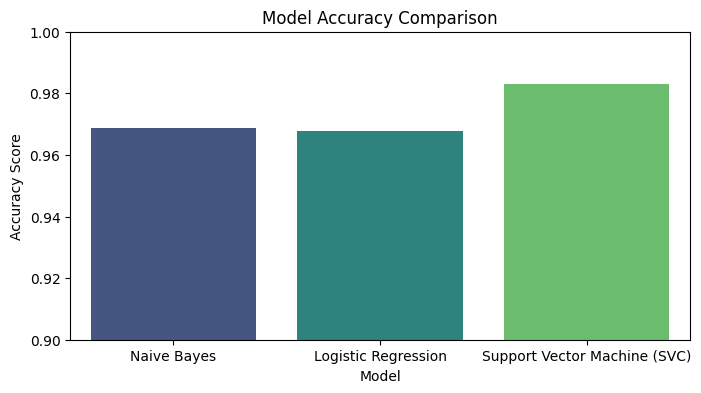

In [9]:
# Plot Accuracy and F1-Score comparison
plt.figure(figsize=(8, 4))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylim(0.9, 1.0)
plt.ylabel('Accuracy Score')
plt.show()

## Step 5: Test Best Model with Custom Input

In [10]:
# Using Support Vector Machine / Best Model for prediction
best_model = models['Support Vector Machine (SVC)']

def predict_spam(message):
    vectorized_msg = tfidf.transform([message])
    pred = best_model.predict(vectorized_msg)[0]
    return "SPAM" if pred == 1 else "HAM (Legitimate)"

# Test
msg1 = "CLAIM YOUR FREE $1000 GIFT CARD NOW! Reply YES to win."
msg2 = "Hey brother, did you finish the assignment yet?"

print(f"Message: {msg1}\nResult: {predict_spam(msg1)}\n")
print(f"Message: {msg2}\nResult: {predict_spam(msg2)}")

Message: CLAIM YOUR FREE $1000 GIFT CARD NOW! Reply YES to win.
Result: SPAM

Message: Hey brother, did you finish the assignment yet?
Result: HAM (Legitimate)
